# S&P 500 Stock Behaviour and Risk Analysis

### Objective: 
We cannot predict all stocks equally, this projects atests to this by grouping six popular  stocks chosen from different sectors- Apple, NVIDIA, JPMorgan, ExxonMobil, Amazon and Lockheed Martin. we analyse their behaviour (volatility, risk and movements) rather than sector and use this insights to decide how confident we are in its forecast and what it would mean to hold them together in a portfolio. We then extrapolate this to a tool built for assesing S&P 500 stocks correlation, volatility and risks.

### S&P 500 Companies:
Apple (AAPL)          : Consumer technology

NVIDIA (NVIDA)        : Semiconductors

JPMorgan (JPM)        : Finance

ExxonMobil (XOM)      : Energy

Amazon  (AMZN)        : e-commerce

Lockheed Martin (LMT) : Defence

### Approach:
1. Exploratory Data Analysis : trends, returns and volatility
2. Anomaly detection : flagging unusual shocks before modelling
3. Correlation Analysis : testing if linked stocks actually have same patterns
4. Clustering : grouping by volatility
5. Forecasting : model choice and confidence derived from the cluster
6. Apriori (Association Rule Mining) : exploratory pass asssesing movements in the stock


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ['AAPL', 'NVDA','JPM', 'XOM', 'AMZN', 'LMT']
df = yf.download(tickers, start='2020-01-01', end='2026-06-17', threads=False)
close = df['Close'] 
close.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,JPM,LMT,NVDA,XOM
Date,,,,,,
2020-01-02,72.333870,94.900497,118.430351,335.413391,5.963803,52.947029
2020-01-03,71.630661,93.748497,116.867462,347.482147,5.868347,52.521362
2020-01-06,72.201401,95.143997,116.774529,346.952972,5.892957,52.924644
2020-01-07,71.861855,95.343002,114.789314,348.120483,5.964301,52.491493
2020-01-08,73.017845,94.598503,115.684784,345.206177,5.975488,51.699902


### 1. EDA

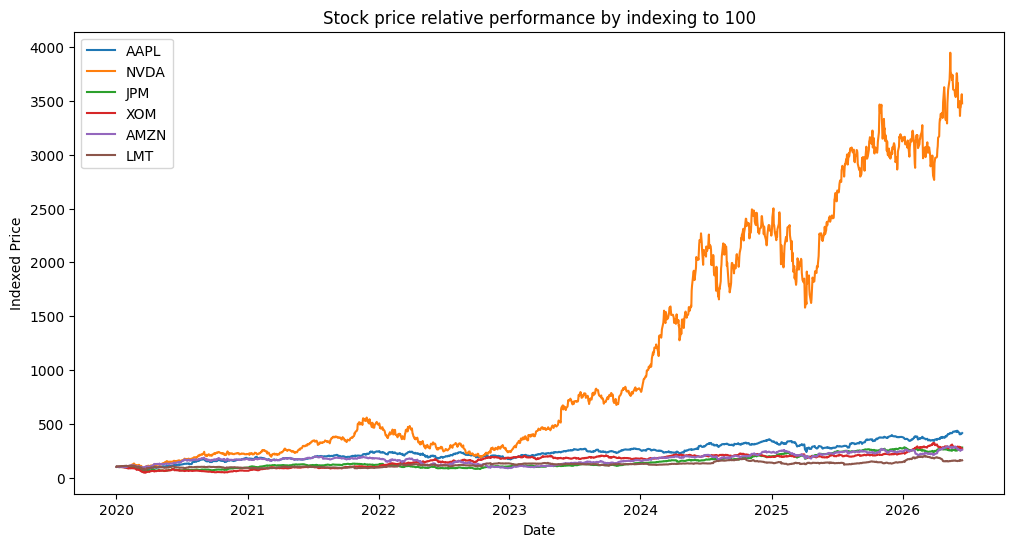

In [5]:
# Indexing the prices to compare aginst each other since raw prices aren't comparable as is
norm = close/ close.iloc[0] * 100 #dividing each stock's price by its price on the first day and multiplying by 100 to set the starting point to 100 for all stocks, allowing for a relative performance comparison over time
plt.figure(figsize=(12,6))
for tick in tickers:
    plt.plot(norm.index, norm[tick], label = tick)
plt.title("Stock price relative performance by indexing to 100")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.legend()
plt.show()
    

In [6]:
# Calculating the returns (preping for correlation and anomaly detection)
returns = close.pct_change().dropna() #calculating change in consecutive prices and dropping the first row since it doesnt have anything to comapre it with
returns.head()

Ticker,AAPL,AMZN,JPM,LMT,NVDA,XOM
Date,,,,,,
2020-01-03,-0.009722,-0.012139,-0.013197,0.035982,-0.016006,-0.008039
2020-01-06,0.007968,0.014886,-0.000795,-0.001523,0.004194,0.007678
2020-01-07,-0.004703,0.002092,-0.017000,0.003365,0.012107,-0.008184
2020-01-08,0.016086,-0.007809,0.007801,-0.008372,0.001876,-0.015080
2020-01-09,0.021241,0.004799,0.003651,0.009488,0.010983,0.007656


Ticker
NVDA    0.522814
AMZN    0.353587
XOM     0.326409
AAPL    0.313435
JPM     0.309447
LMT     0.263550
dtype: float64


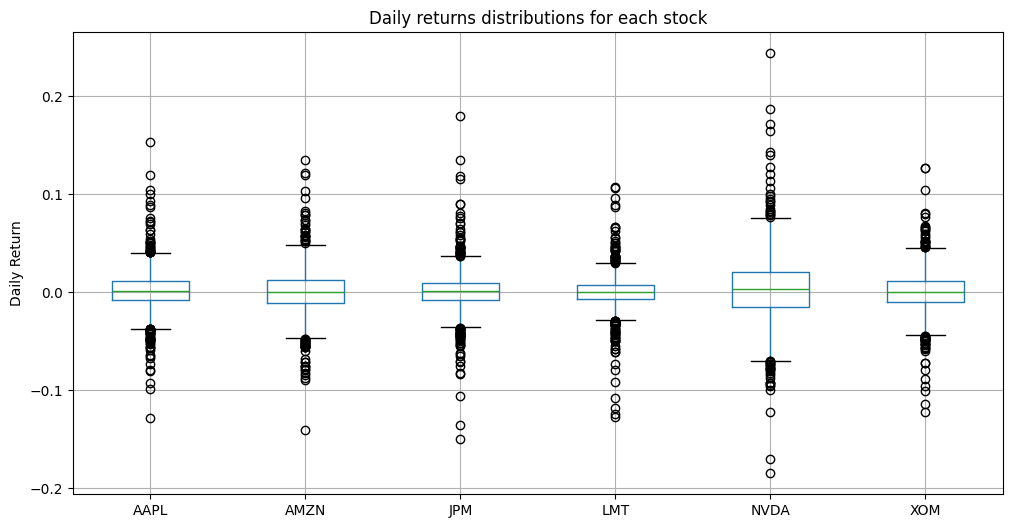

In [7]:
# Calculating distribution and volatility ranking
annual_vol = returns.std() * np.sqrt(252) #annualizing the volatility by multiplying the standard deviation of returns by the square root of 252 (the number of trading days in a year)
print(annual_vol.sort_values(ascending = False)) #the stocks in descending volatility

plt.figure(figsize=(12,6))
returns.boxplot()
plt.title("Daily returns distributions for each stock")
plt.ylabel("Daily Return")
plt.show()

####  
We can observe after normalization, NVIDIA relative prices have the highest swings and even in terms of growth, however an observed dip in 2023 is obeserved, which we will analyse through anomaly detection.
When returns were calculated, and plotted using boxplots, the daily returns for NVIDIA showed dispersion from the mean while Lockheed Martin followed by JPMorgan had the least dispersion.
The annualized volatility confirms this by observing that NVIDIA has a 52% volatility compared to Lockheed Martin which is at 26%, almost double that of NVIDIA. 
Lockheed Martin is a defensive stock figuratevely and literally. Characterised by its long term government contracts thus, less sensitive to economic cycles.
We can observe cluster formation already from this: NVDA as highly volatile, AMZN as next most volatile, XOM, AAPL, JPM as moderately volatile and LMT as last volatile

### 2. Anomaly Detection

In [8]:
# Anomaly detection using Z-scores
from scipy import stats
z_scores = returns.apply(stats.zscore) #how many standard deviations each return is from the mean, which helps in detecting outliers
anomalies = z_scores.abs() > 3 #identifying returns that are more than 3 standard deviations away from the mean as anomalies
print(anomalies.sum()) #anomaly count per stock

Ticker
AAPL    23
AMZN    26
JPM     25
LMT     27
NVDA    14
XOM     19
dtype: int64


###
An interesting observation on the anomaly detection, we expected NVDA to have the highest anomalies however, LMT has has almost double. This is because Z-sore are done against the stocks own mean and standard deviation (relative anomalies). NVDA is continually having high swings and hence has a big standard deviation. However for LMT, the standard deviation is small therefore, a small move easily blows past the 3 standard deviations from its baseline. Hence forms a basis on risk in this analysis. We proceed to assess the relative anomalies.

In [9]:
abs_threshold = 0.05 #identifying returns that are greater than 5% in absolute value as anomalies, which can capture significant price movements that may not be flagged by Z-scores alone
jump = returns.abs() > abs_threshold
print(jump.sum())

Ticker
AAPL     35
AMZN     57
JPM      36
LMT      25
NVDA    176
XOM      38
dtype: int64


### Anomaly detection : relative vs. absolute
We observe the relative anomalies is what we expected earlier, NVDA having almost triple that of the next stock. We observe LMT and AMZN are comparatively calmer to the rest as they have the lowest anomalies.
 

In [10]:
comparison = pd.DataFrame({'Relative anomalies':anomalies.sum(), 'Absolute anomalies': jump.sum()})
print(comparison)

        Relative anomalies  Absolute anomalies
Ticker                                        
AAPL                    23                  35
AMZN                    26                  57
JPM                     25                  36
LMT                     27                  25
NVDA                    14                 176
XOM                     19                  38


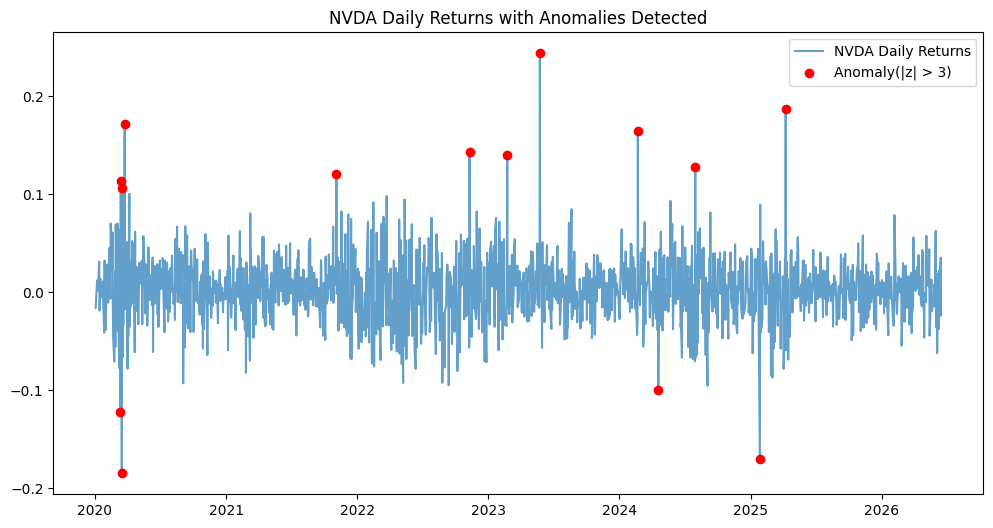

In [11]:
# Days with the anomlies which can identify if  there were events that caused them.
plt.figure(figsize=(12,6))
plt.plot(returns.index, returns['NVDA'], label = 'NVDA Daily Returns', alpha = 0.7)
plt.scatter(returns.index[anomalies['NVDA']], returns['NVDA'][anomalies['NVDA']], color = 'red', label = 'Anomaly(|z| > 3)', zorder = 5 )
plt.title("NVDA Daily Returns with Anomalies Detected")
plt.legend()
plt.show()

### 3. Correlation Analysis

In [12]:
corr_matrix = returns.corr()
corr_matrix

Ticker,AAPL,AMZN,JPM,LMT,NVDA,XOM
Ticker,,,,,,
AAPL,1.000000,0.573760,0.415838,0.240294,0.564062,0.267530
AMZN,0.573760,1.000000,0.296108,0.100354,0.564970,0.116998
JPM,0.415838,0.296108,1.000000,0.353190,0.334839,0.511474
LMT,0.240294,0.100354,0.353190,1.000000,0.098392,0.365199
NVDA,0.564062,0.564970,0.334839,0.098392,1.000000,0.159650
XOM,0.267530,0.116998,0.511474,0.365199,0.159650,1.000000


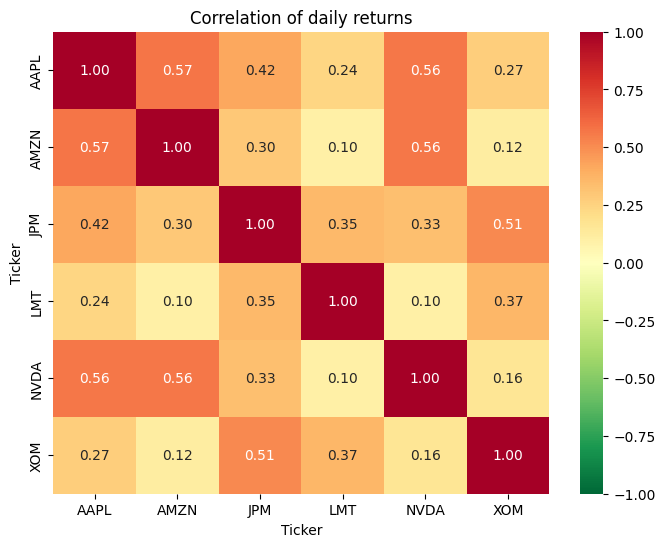

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r", vmin=-1, vmax=1, center=0)
plt.title('Correlation of daily returns')
plt.show()

### Testing three hypotheses
1. NVDA and AAPL : Apple's AI infrastructure(the new Siri) runs on Nvidia cloud compute
2. NVDA and LMT : (weaker case) defense's growing relaince on AI systems suggest a link however no deal confirms this
3. NVDA and JPM : (most diffuse) Nvidia's AI use in financial services 

In [14]:
pairs = [('NVDA', 'AAPL'), ('NVDA', 'LMT'),('NVDA','JPM')]
for s1, s2 in pairs:
    print(f"{s1}-{s2}: {corr_matrix.loc[s1,s2]:.2f}")

NVDA-AAPL: 0.56
NVDA-LMT: 0.10
NVDA-JPM: 0.33


### Correlation : narrative strength vs the statistical evidence
We observe NVDA-AAPL correlation is strongest at 0.56 showing the narrative did produce the strongest correlation. However, the other two shows an interesting turn of events. NVDA-JPM showed a correlation stronger than that of NVDA-LMT. This comes from the shared exposure to market conditions rather than a business relationship. Both NVDA & JPM are highly sensitive to market sentiments. For LMT the stock itself is not moved by the daily market sentiments. We can see this further even if we do a market-beta analysis by correlation these stocks to the index itself. Therefore, correlation reflects shared exposure to boroad market conditions and not necessarily to specific business narratives.

In [15]:
spy = yf.download('^GSPC', start='2020-01-01', threads=False)["Close"].squeeze()
spy_returns = spy.pct_change().dropna()
spy_returns.name = 'SP500'

combined = returns.join(spy_returns)
market_corr = combined.corr()['SP500'].drop('SP500')

comparison = pd.DataFrame({'Corr with S&P':market_corr, 'Corr with NVDA':corr_matrix.loc['NVDA'].drop('NVDA')})
comparison

[*********************100%***********************]  1 of 1 completed


,Corr with S&P,Corr with NVDA
AAPL,0.771915,0.564062
AMZN,0.653855,0.564970
JPM,0.703713,0.334839
LMT,0.403545,0.098392
NVDA,0.701561,NaN
XOM,0.464768,0.159650


### 4. Clustering 
Grouping the stocks based on their behaviour not sector. Volatility and the avergae returns need scaling before we can proceed because volatility currently would decide every cluster as average return values are smaller hence would be overlooked.

In [16]:
features = pd.DataFrame({
    'volatility': returns.std() *(252**0.5),
    'average_return': returns.mean()*252
})
features

,volatility,average_return
Ticker,,
AAPL,0.313435,0.269791
AMZN,0.353587,0.210517
JPM,0.309447,0.207627
LMT,0.263550,0.107832
NVDA,0.522814,0.687984
XOM,0.326409,0.206554


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features

array([[-0.421314  , -0.06350304],
       [ 0.06518375, -0.37910431],
       [-0.46963563, -0.39449255],
       [-1.02573181, -0.92585181],
       [ 2.11561026,  2.16315873],
       [-0.26411257, -0.40020701]])

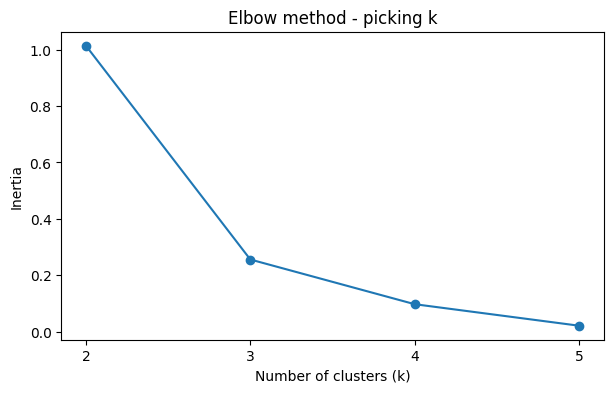

In [19]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2,6)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method - picking k")
plt.xticks(k_range)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster' ]= kmeans.fit_predict(scaled_features)
features

,volatility,average_return,cluster
Ticker,,,
AAPL,0.313435,0.269791,0
AMZN,0.353587,0.210517,0
JPM,0.309447,0.207627,0
LMT,0.263550,0.107832,2
NVDA,0.522814,0.687984,1
XOM,0.326409,0.206554,0


KeyError: np.float64(0.0)

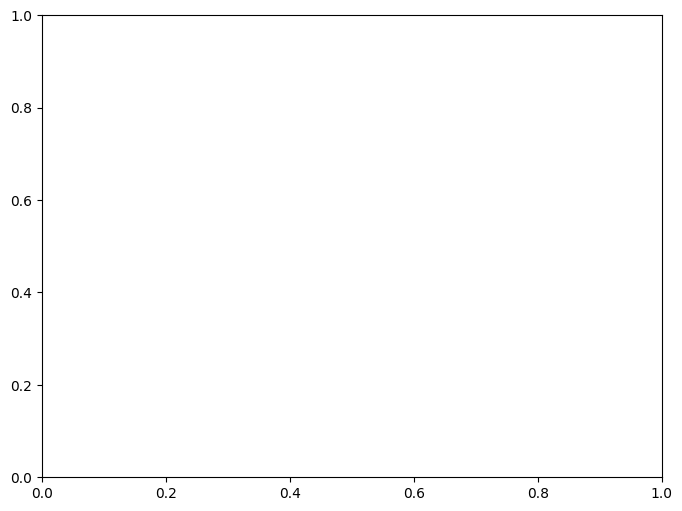

In [ ]:
cluster_names = {1: 'High volatility', 0:'Moderate volatility', 2:'low volatility'}
col = {'High volatility': '#e74c3c', 'Moderate volatility':'#3498db', 'Low volatility':'#2ecc71'}
labels= {0: 'Cluster 0', 1:'Cluster 1', 2:'Cluster 2'}
fig, ax = plt.subplots(figsize=(8,6))
for ticker, row in features.iterrows():
    cluster_name = cluster_names[row['cluster']]
    ax.scatter(row['volatility'], row['average_return'], c=col[cluster_name], label=labels[int(row['cluster'])])
    ax.annotate(ticker, (row['volatility'], row['average_return']), textcoords="offset points", xytext=(0,10), ha='center')
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Average Return')
ax.set_title('S&P 500 stock clusters by volatility and return')
plt.show()